In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [56]:
shop_df=pd.read_csv("shop_smart_ecommerce.csv")
shop_df.head()
shop_df.info()
shop_df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [57]:
shop_df.tail(20)



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12310,1,5.000000,0,0.00,21,411.083333,0.015789,0.016140,0.000000,0.0,Nov,3,2,7,3,Returning_Visitor,False,False
12311,1,0.000000,2,211.25,144,4627.489571,0.001361,0.020664,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,False,True
12312,7,150.357143,1,9.00,221,11431.001240,0.011149,0.021904,1.582473,0.0,Nov,2,5,1,2,Returning_Visitor,True,True
12313,3,16.000000,3,86.00,15,2773.500000,0.000000,0.030000,78.811725,0.0,Dec,2,2,1,2,Returning_Visitor,False,True
12314,0,0.000000,0,0.00,7,705.833333,0.028571,0.085714,0.000000,0.0,Dec,5,11,4,1,Returning_Visitor,True,False
12315,0,0.000000,0,0.00,7,212.500000,0.000000,0.033333,0.000000,0.0,Nov,3,2,1,11,Returning_Visitor,True,False
12316,0,0.000000,0,0.00,44,615.000000,0.013636,0.036364,0.000000,0.0,Dec,4,1,3,1,Returning_Visitor,False,False
12317,3,100.500000,0,0.00,95,1453.640882,0.002105,0.012761,0.000000,0.0,Dec,2,2,3,2,New_Visitor,False,False
12318,0,0.000000,0,0.00,6,279.000000,0.000000,0.033333,0.000000,0.0,Dec,1,2,3,10,Returning_Visitor,True,False
12319,0,0.000000,0,0.00,21,1128.583333,0.000000,0.013043,3.685401,0.0,Dec,2,2,1,2,Returning_Visitor,False,False


In [58]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
shop_df["Weekend"]=le.fit_transform(shop_df["Weekend"])
shop_df["Revenue"]=le.fit_transform(shop_df["Revenue"])
shop_df.head()
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore',drop="first", sparse_output=False)
encoded=enc.fit_transform(shop_df[["VisitorType"]])

encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(["VisitorType"]), index=shop_df.index)#change in dataframe 

df = pd.concat([shop_df.drop(columns="VisitorType"), encoded_df], axis=1)#old columns delete and new columns are concatenate


In [59]:
shop_df.columns
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,0,0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,0,0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,0,0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,0,0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,1,0,0.0,1.0


In [60]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=["Revenue","Month"],axis=1)
Y=df["Revenue"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.head()
X_test.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,VisitorType_Other,VisitorType_Returning_Visitor
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,1,8,6,11,0,0.0,1.0
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,2,2,3,2,0,0.0,1.0
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,2,2,2,2,0,0.0,1.0
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,2,5,7,4,0,0.0,1.0
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,2,2,3,1,1,0.0,1.0


In [61]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [62]:
Y_pred=model.predict(X_test)
Y_pred

array([0, 1, 1, ..., 0, 1, 0], shape=(2466,))

In [63]:
from sklearn.metrics import accuracy_score
Y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(Y_test, Y_pred))

accuracy:  0.8564476885644768


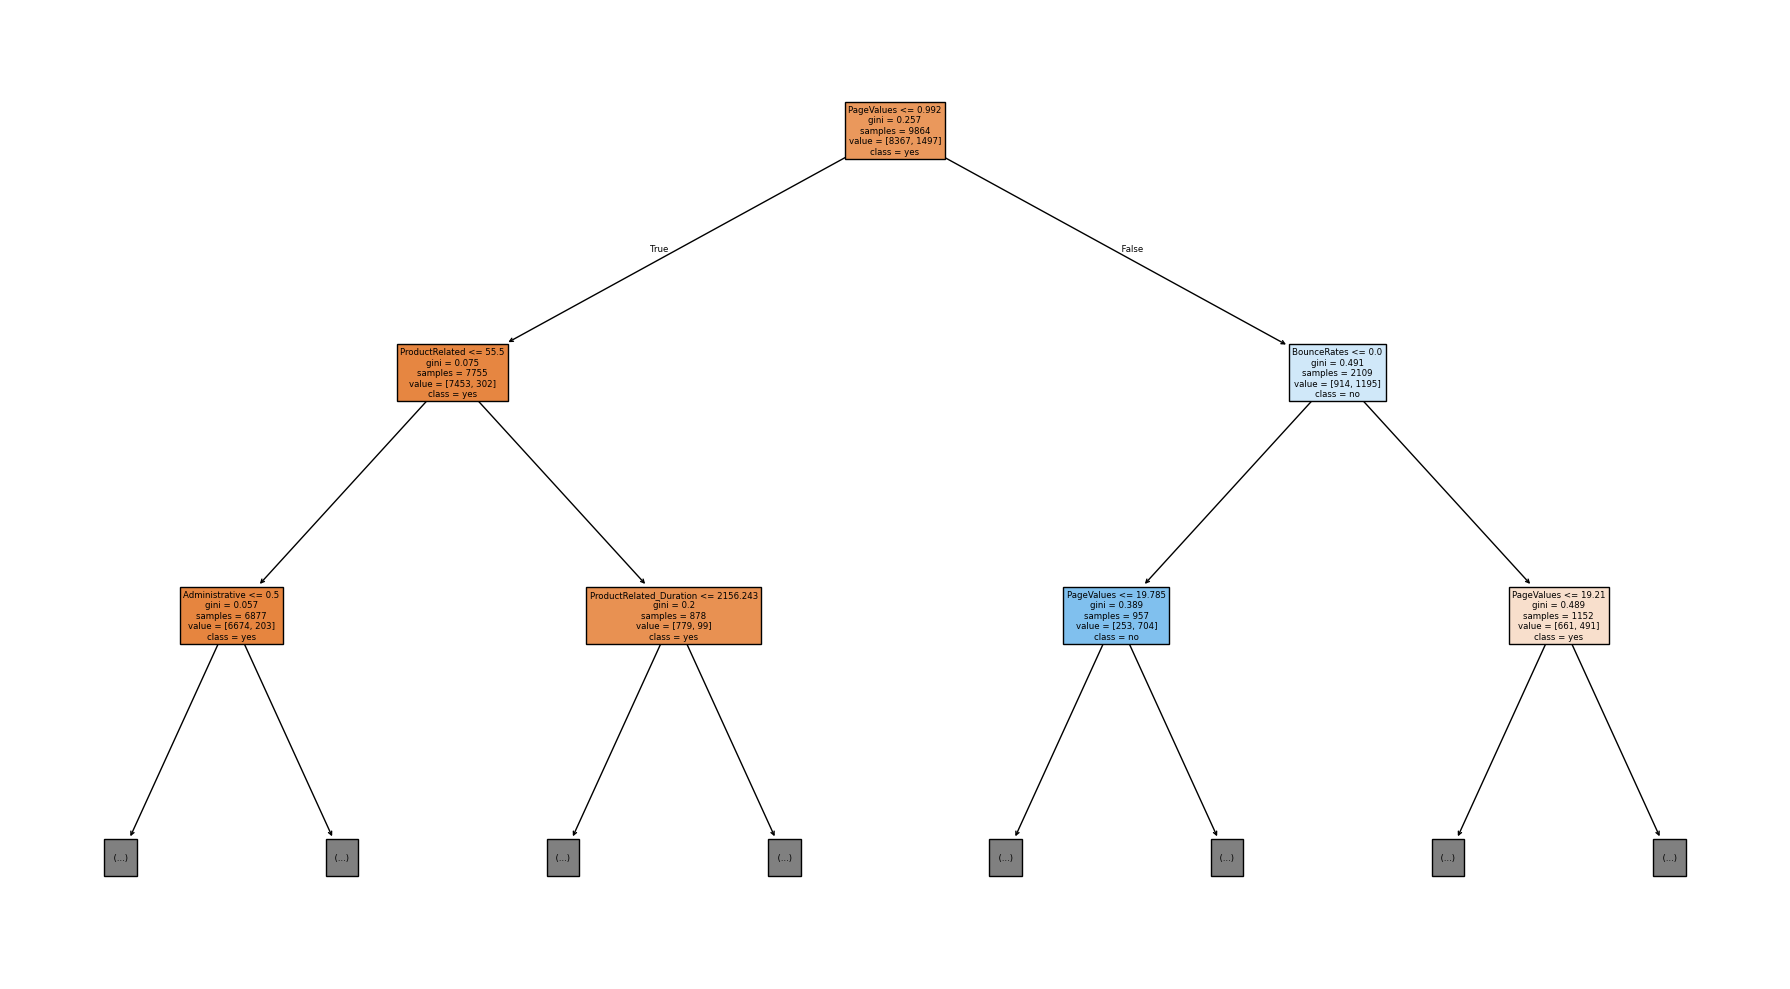

accuracy:  0.8564476885644768


In [64]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["yes", "no"],
    filled=True,
    max_depth=2
    
)

plt.tight_layout()
plt.show()
from sklearn.metrics import accuracy_score
Y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(Y_test, Y_pred))



In [65]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)

    acc = model.score(X_test, Y_test)
    print(f"for depth={depth}, accuracy={acc}")


for depth=2, accuracy=0.8763179237631792
for depth=3, accuracy=0.8791565287915653
for depth=4, accuracy=0.8819951338199513
for depth=5, accuracy=0.8815896188158961
for depth=6, accuracy=0.878345498783455
for depth=7, accuracy=0.8767234387672344
for depth=8, accuracy=0.8791565287915653
for depth=9, accuracy=0.8738848337388483
for depth=10, accuracy=0.8738848337388483


In [66]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, Y_train)

    acc = model.score(X_test, Y_test)
    print(f"for sample split={split}, accuracy={acc}")


for sample split=5, accuracy=0.8819951338199513
for sample split=10, accuracy=0.8819951338199513
for sample split=15, accuracy=0.8819951338199513
for sample split=20, accuracy=0.8819951338199513
for sample split=25, accuracy=0.8819951338199513
for sample split=30, accuracy=0.8819951338199513
